# TP2 — Detector de máximo enfoque en video

**Objetivo.** Detectar el frame de máximo enfoque en `focus_video.mov` con la métrica espectral de De & Masilamani (*Image Sharpness Measure for Blurred Images in Frequency Domain*) y visualizarlo.

**Tres experimentos.**
1. Métrica sobre el frame completo.
2. Métrica sobre una ROI central (≈10% del área).
3. Matriz de enfoque por bloques (grid 6×8) superpuesta al frame.

**Extra:** Unsharp masking para expandir la zona enfocada.

## Métrica FM (Image Quality Measure)

Se define 
$$FM = \frac{T_H}{M \cdot N}$$

Donde $T_H$ es el número total de píxeles en F cuyos valores son mayores que $M/1000$, y M.N es el tamaño de la imagen o Height x Weight

In [50]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)

cap = cv2.VideoCapture(str('focus_video.mov'))

FRAMES = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
FPS      = cap.get(cv2.CAP_PROP_FPS)
H_FRAME  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
W_FRAME  = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()
print(f'cap: {W_FRAME}x{H_FRAME} - {FPS:.1f} fps, {N_FRAMES} frames')

cap: 360x640 - 30.0 fps, 171 frames


In [51]:
def sharpness_fft(gray, thr_ratio=1000.0):
    if gray.dtype != np.float32:
        gray = gray.astype(np.float32)
    AF = np.abs(np.fft.fftshift(np.fft.fft2(gray)))
    M = AF.max()
    if M == 0:
        return 0.0
    return np.count_nonzero(AF > M / thr_ratio) / float(gray.size)

## Tres experimentos

- **Frame completo:** la métrica responde a toda la escena; el fondo aporta bordes propios y puede ensuciar la curva.
- **ROI central (10% del área):** Elijo ROI cuadrada para no introducir anisotropías en la FFT.
- **Grid 6×8:** da un mapa espacial de nitidez (a menor bloque más ruido).

In [52]:
def to_gray(frame):
    return cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

def center_roi(shape, frac_area=0.10):
    H, W = shape[:2]
    side = int(np.sqrt(frac_area * H * W))
    y0 = (H - side) // 2
    x0 = (W - side) // 2
    return y0, x0, side

def focus_grid(gray, grid=(6, 8)):
    H, W = gray.shape
    gh, gw = grid
    bh, bw = H // gh, W // gw
    M = np.zeros(grid, dtype=np.float32)
    for i in range(gh):
        for j in range(gw):
            M[i, j] = sharpness_fft(gray[i*bh:(i+1)*bh, j*bw:(j+1)*bw])
    return M

In [58]:
cap = cv2.VideoCapture(str('focus_video.mov'))
fm_full, fm_roi, fm_grid_mean = [], [], []
grid_cache = []
frames_cache = {}
GRID = (6, 8)
ROI_FRAC = 0.10
KEEP_EVERY = max(1, FRAMES // 20)

t0 = time.perf_counter()
idx = 0
while True:
    ok, frame = cap.read()
    if not ok:
        break
    g = to_gray(frame)

    fm_full.append(sharpness_fft(g))
    y0, x0, s = center_roi(g.shape, ROI_FRAC)
    fm_roi.append(sharpness_fft(g[y0:y0+s, x0:x0+s]))
    M = focus_grid(g, GRID)
    fm_grid_mean.append(float(M.mean()))
    grid_cache.append(M)

    if idx % KEEP_EVERY == 0:
        frames_cache[idx] = frame
    idx += 1

cap.release()
fm_full = np.array(fm_full)
fm_roi = np.array(fm_roi)
fm_grid_mean = np.array(fm_grid_mean)

## Detección automática del pico

Suavizado por promedio móvil (ventana `k=5`) antes de `argmax`. Sin el suavizado, un único frame con ruido puede desplazar el pico un par de posiciones; con ventanas demasiado grandes, el pico se ensancha y se corre temporalmente. `k=5` es el compromiso.

In [54]:
def smooth(x, k=5):
    if k <= 1:
        return x
    return np.convolve(x, np.ones(k) / k, mode='same')

def auto_peak(curve, k=5):
    return int(np.argmax(smooth(curve, k)))

peak_full = auto_peak(fm_full)
peak_roi  = auto_peak(fm_roi)
peak_grid = auto_peak(fm_grid_mean)
print(f'Pico: full={peak_full}, ROI={peak_roi}, grid={peak_grid}')

Pico: full=109, ROI=111, grid=109


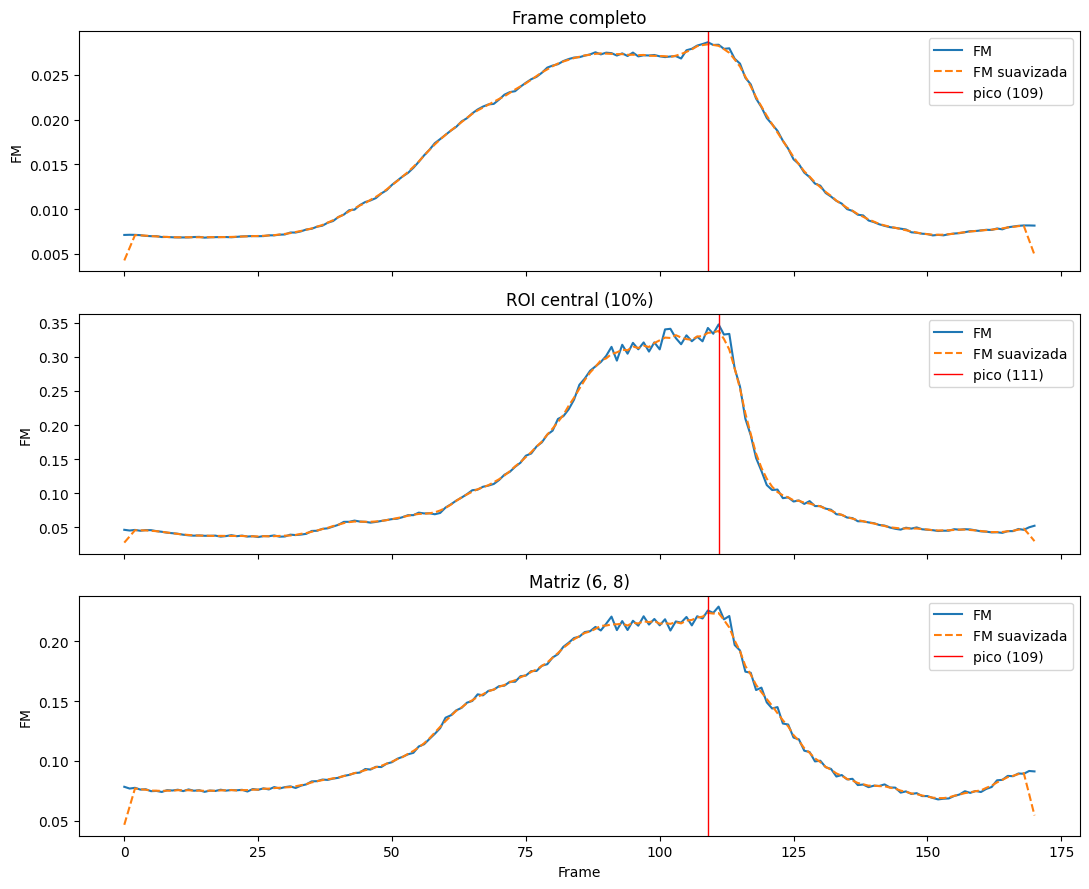

In [42]:
fig, ax = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
for a, y, p, t in zip(ax,
                       [fm_full, fm_roi, fm_grid_mean],
                       [peak_full, peak_roi, peak_grid],
                       ['Frame completo', f'ROI central ({int(ROI_FRAC*100)}%)', f'Matriz {GRID}']):
    a.plot(y, label='FM')
    a.plot(smooth(y), '--', label='FM suavizada')
    a.axvline(p, color='r', lw=1, label=f'pico ({p})')
    a.set_title(t); a.set_ylabel('FM'); a.legend(loc='best')
ax[-1].set_xlabel('Frame')
plt.tight_layout(); plt.show()

## Matriz de enfoque superpuesta al frame de máximo enfoque

La matriz `6×8` de FM por bloque se normaliza a `[0,1]`, se lleva a `uint8` y se pasa por `COLORMAP_JET`. Se fusiona con el frame por `addWeighted` (α = 0.45). Los bloques más rojos concentran más nitidez.

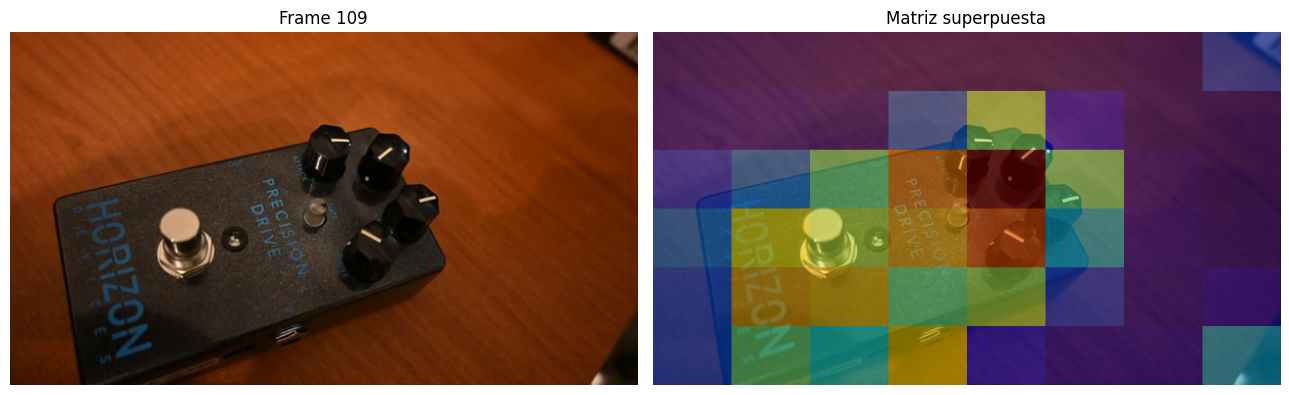

In [56]:
def overlay_focus_map(frame_bgr, M, alpha=0.45):
    H, W = frame_bgr.shape[:2]
    Mn = (M - M.min()) / (np.ptp(M) + 1e-9)
    heat = cv2.resize((Mn * 255).astype(np.uint8), (W, H), interpolation=cv2.INTER_NEAREST)
    heat_color = cv2.applyColorMap(heat, cv2.COLORMAP_JET)
    return cv2.addWeighted(frame_bgr, 1 - alpha, heat_color, alpha, 0)

def get_frame(idx):
    if idx in frames_cache:
        return frames_cache[idx]
    cap = cv2.VideoCapture(str('focus_video.mov'))
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ok, frame = cap.read()
    cap.release()
    return frame

best_frame = get_frame(peak_grid)
overlay = overlay_focus_map(best_frame, grid_cache[peak_grid])

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].imshow(cv2.cvtColor(best_frame, cv2.COLOR_BGR2RGB)); ax[0].set_title(f'Frame {peak_grid}'); ax[0].axis('off')
ax[1].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)); ax[1].set_title('Matriz superpuesta'); ax[1].axis('off')
plt.tight_layout(); plt.show()

## Unsharp masking 

`sharp = I + amount · (I − G_σ * I)`. Realza bordes (sube `FM`) pero también amplifica ruido si `amount` es grande.

FM original: 0.0286   |   FM unsharp: 0.0628   (x2.19)


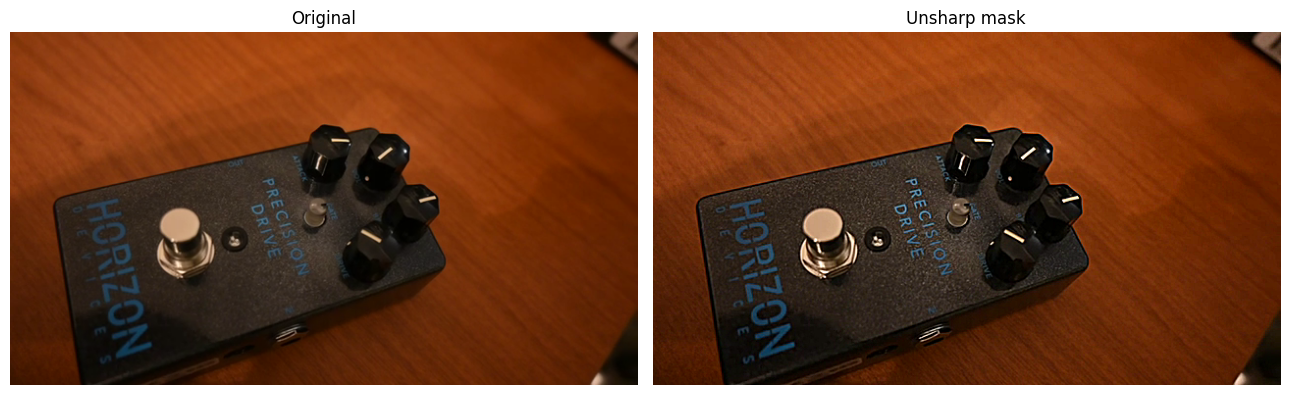

In [57]:
def unsharp_mask(img, sigma=1.5, amount=1.5):
    blur = cv2.GaussianBlur(img, (0, 0), sigmaX=sigma)
    return cv2.addWeighted(img, 1 + amount, blur, -amount, 0)

sharp = unsharp_mask(best_frame, sigma=1.5, amount=1.5)
fm_orig  = sharpness_fft(to_gray(best_frame))
fm_sharp = sharpness_fft(to_gray(sharp))
print(f'FM original: {fm_orig:.4f}   |   FM unsharp: {fm_sharp:.4f}   (x{fm_sharp/fm_orig:.2f})')

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].imshow(cv2.cvtColor(best_frame, cv2.COLOR_BGR2RGB)); ax[0].set_title('Original'); ax[0].axis('off')
ax[1].imshow(cv2.cvtColor(sharp,     cv2.COLOR_BGR2RGB)); ax[1].set_title('Unsharp mask'); ax[1].axis('off')
plt.tight_layout(); plt.show()

## Conclusiones

- La métrica FM discrimina enfoque/desenfoque a lo largo del video sin referencia.
- Los tres experimentos detectan el pico en frames muy cercanos, lo que valida la detección automática.
- La ROI central es la curva más limpia cuando el sujeto está centrado; el frame completo introduce ruido por el fondo.
- La matriz de enfoque habilita un mapa espacial (útil como base de un autofoco por regiones).
- Unsharp masking aumenta la FM y expande visualmente la zona percibida como nítida.